# ESC-50: MFCC + Random Forest baseline

The reference baseline of the ESC-50 paper summarizes each clip with MFCC (and zero-crossing rate)
statistics and classifies them with a random forest: **44.3%** accuracy over the 5 official folds.
This notebook reproduces it, and then measures how much a random split, which ignores that some
clips come from the same recording, inflates that number.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

from audiolab.esc50 import GROUPS, load_clip, load_metadata
from audiolab.evaluation import fold_accuracies, predict_on_folds, random_folds
from audiolab.features import extract_mfcc_features

ROOT = Path("../data/ESC-50")
CACHE = Path("../data/cache")
GROUP_COLORS = dict(zip(GROUPS, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]))

meta = load_metadata(ROOT)
y = meta.target.to_numpy()
folds = meta.fold.to_numpy()
class_names = meta.drop_duplicates("target").set_index("target").category.sort_index()

## 1. Features

Each clip becomes 40 numbers: the mean and standard deviation over time of 20 MFCCs.
Computing them takes a while, so they are cached in `data/cache/`.

In [2]:
cache_file = CACHE / "esc50_mfcc.npy"
if cache_file.exists():
    X = np.load(cache_file)
else:
    X = np.array([extract_mfcc_features(*load_clip(ROOT, fn)) for fn in meta.filename])
    CACHE.mkdir(exist_ok=True)
    np.save(cache_file, X)
print("Features:", X.shape)

Features: (2000, 40)


## 2. Official folds

In [3]:
model = RandomForestClassifier(n_estimators=500, random_state=0, n_jobs=-1)

pred = predict_on_folds(model, X, y, folds)
official = fold_accuracies(y, pred, folds)

for k, acc in enumerate(official, start=1):
    print(f"Fold {k}: {acc:.1%}")
print(f"Mean:   {official.mean():.1%} ± {official.std():.1%}   (paper: 44.3%)")

Fold 1: 44.5%
Fold 2: 51.0%
Fold 3: 48.2%
Fold 4: 47.2%
Fold 5: 47.2%
Mean:   47.6% ± 2.1%   (paper: 44.3%)


## 3. Which classes are hard?

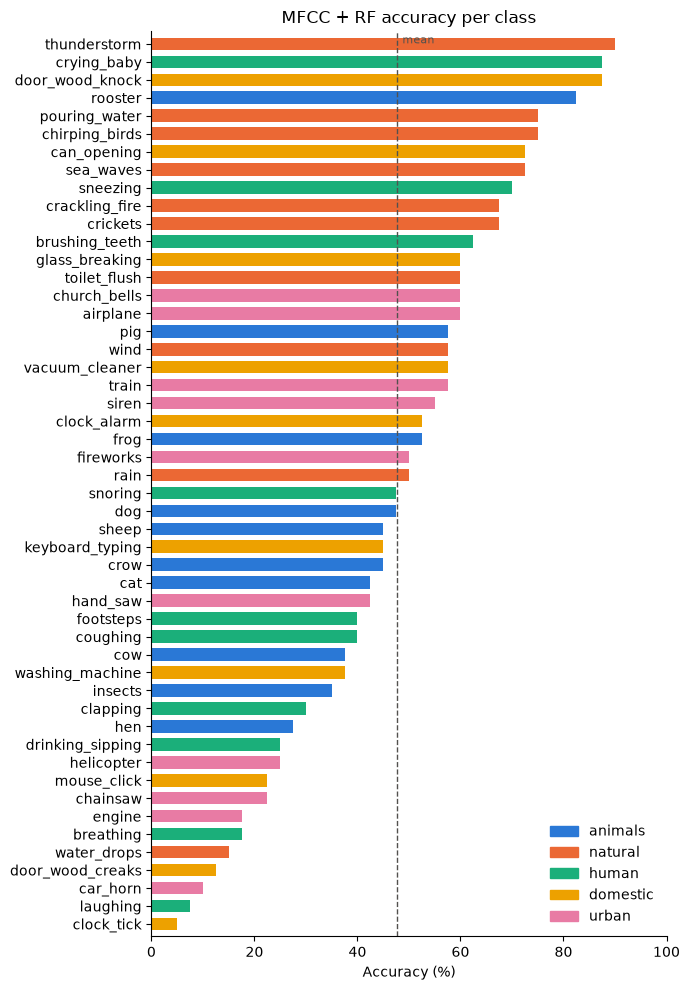

In [4]:
results = pd.DataFrame({"true": meta.category, "pred": class_names[pred].to_numpy(), "group": meta.group})
results["correct"] = results.true == results.pred

per_class = results.groupby(["true", "group"]).correct.mean().reset_index().sort_values("correct")

fig, ax = plt.subplots(figsize=(7, 10))
ax.barh(per_class.true, per_class.correct * 100, height=0.7,
        color=[GROUP_COLORS[g] for g in per_class.group])
ax.axvline(official.mean() * 100, color="#52514e", linewidth=1, linestyle="--")
ax.annotate("mean", (official.mean() * 100, len(per_class) - 0.5), xytext=(4, 0),
            textcoords="offset points", fontsize=8, color="#52514e", va="top")
ax.set_xlabel("Accuracy (%)")
ax.set_xlim(0, 100)
ax.set_ylim(-0.7, len(per_class) - 0.3)
ax.set_title("MFCC + RF accuracy per class")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in GROUP_COLORS.values()],
          labels=GROUPS, loc="lower right", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [5]:
print("Most frequent confusions (true -> predicted, out of 40 clips per class):")
results[~results.correct].value_counts(["true", "pred"]).head(10)

Most frequent confusions (true -> predicted, out of 40 clips per class):


true       pred           
coughing   sneezing           11
chainsaw   toilet_flush        9
breathing  keyboard_typing     9
siren      church_bells        8
engine     wind                7
hand_saw   toilet_flush        7
laughing   crying_baby         7
clapping   sea_waves           7
chainsaw   sea_waves           6
hen        dog                 6
Name: count, dtype: int64

## 4. Data leakage: random folds vs. official folds

Same features, same model: only the assignment of clips to folds changes. With random folds,
clips from the same recording can land on both sides of the split. Five different random splits
make sure the difference is not luck.

In [6]:
leaky = np.array([fold_accuracies(y, predict_on_folds(model, X, y, rf), rf).mean()
                  for rf in (random_folds(y, seed=s) for s in range(5))])

print(f"Official folds: {official.mean():.1%}")
print(f"Random folds:   {leaky.mean():.1%}   (5 random splits, from {leaky.min():.1%} to {leaky.max():.1%})")
print(f"Inflation:      {100 * (leaky.mean() - official.mean()):+.1f} points")

Official folds: 47.6%
Random folds:   58.2%   (5 random splits, from 57.6% to 58.8%)
Inflation:      +10.6 points


If the gain comes from recognizing the recording, it should appear only in the clips that have a
*sibling* (another clip of the same class cut from the same recording) in the training set.

In [7]:
rf = random_folds(y, seed=0)
pred_random = predict_on_folds(model, X, y, rf)

has_sibling_in_train = np.array([
    ((meta.src_file == s) & (meta.target == t) & (rf != f)).any()
    for s, t, f in zip(meta.src_file, meta.target, rf)
])

table = pd.DataFrame({
    "clips": [has_sibling_in_train.sum(), (~has_sibling_in_train).sum()],
    "official folds": [np.mean(pred[m] == y[m]) for m in (has_sibling_in_train, ~has_sibling_in_train)],
    "random folds": [np.mean(pred_random[m] == y[m]) for m in (has_sibling_in_train, ~has_sibling_in_train)],
}, index=["sibling in training (random split)", "no sibling in training"])
table.style.format({"official folds": "{:.1%}", "random folds": "{:.1%}"})

,clips,official folds,random folds
sibling in training (random split),698,48.7%,73.6%
no sibling in training,1302,47.1%,49.9%


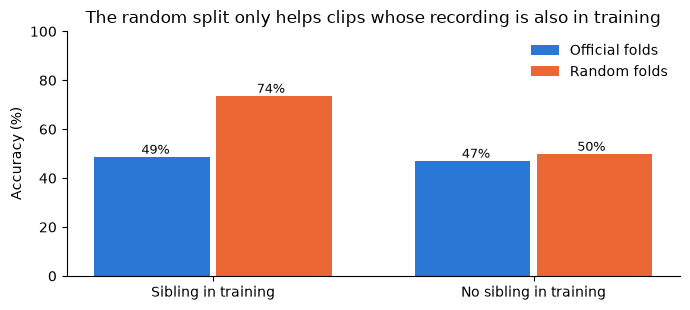

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.2))
groups = ["Sibling in training", "No sibling in training"]
x = np.arange(len(groups))
w = 0.36
ax.bar(x - w/2 - 0.01, table["official folds"] * 100, w, color="#2a78d6", label="Official folds")
ax.bar(x + w/2 + 0.01, table["random folds"] * 100, w, color="#eb6834", label="Random folds")
for i, (a, b) in enumerate(zip(table["official folds"], table["random folds"])):
    ax.annotate(f"{a:.0%}", (i - w/2, a * 100), ha="center", va="bottom", fontsize=9, color="#0b0b0b")
    ax.annotate(f"{b:.0%}", (i + w/2, b * 100), ha="center", va="bottom", fontsize=9, color="#0b0b0b")
ax.set_xticks(x, groups)
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 100)
ax.set_title("The random split only helps clips whose recording is also in training")
ax.legend(frameon=False, loc="upper right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 5. Can we remove the fingerprint? Cepstral mean normalization

In the cepstral domain a convolution becomes a sum: $y = x * h \Rightarrow \text{MFCC}(y) \approx
\text{MFCC}(x) + \text{MFCC}(h)$. The channel $h$ is constant over the clip, so it sits in the
*mean* of each MFCC over time. Subtracting that mean (cepstral mean normalization, CMN, classic in
speech recognition) removes it. The standard deviation does not change when a constant is
subtracted, so with our features CMN is simply keeping the 20 standard deviations only.

In [9]:
CONTINUOUS = ["rain", "wind", "sea_waves", "engine", "train", "airplane", "vacuum_cleaner",
              "washing_machine", "helicopter", "crickets"]
continuous = meta.category.isin(CONTINUOUS).to_numpy()

rows = {}
for name, cols in [("mean + std (40)", slice(None)), ("std only = CMN (20)", slice(20, None))]:
    p_official = predict_on_folds(model, X[:, cols], y, folds)
    p_random = predict_on_folds(model, X[:, cols], y, rf)
    rows[name] = {
        "official folds": np.mean(p_official == y),
        "random folds": np.mean(p_random == y),
        "leakage (points)": 100 * (np.mean(p_random == y) - np.mean(p_official == y)),
        "continuous classes": np.mean(p_official[continuous] == y[continuous]),
        "other classes": np.mean(p_official[~continuous] == y[~continuous]),
    }
pd.DataFrame(rows).T.style.format("{:.1%}").format("{:+.1f}", subset=["leakage (points)"])

,official folds,random folds,leakage (points),continuous classes,other classes
mean + std (40),47.6%,58.2%,+10.5,50.2%,47.0%
std only = CMN (20),31.5%,36.2%,+4.7,23.8%,33.4%


## Conclusions

- **Baseline reproduced**: 47.6% ± 2.1% over the official folds, in line with the paper's 44.3%
  (which also used zero-crossing rate and a different MFCC implementation). Chance is 2%.
- **A random split reports 58.2%**: 10.6 points of accuracy that are not real, and the 5 random
  splits agree (57.6% to 58.8%), so it is not luck.
- **The inflation is where the theory says**: clips with a sibling in training jump from 49% to 74%,
  the rest barely move (47% to 50%). The model recognizes *recordings* (microphone, room, background),
  not only sounds.
- **CMN halves the leakage but does not remove it, and costs a lot**: +4.7 points instead of +10.5,
  because it removes the convolutive part of the fingerprint ($h$) but not the additive background
  noise ($n$). Accuracy drops to 31.5%, and continuous sounds (rain, engine, wind...) fall from 50%
  to 24%: their information is mostly in the mean, which mixes the timbre of the sound with the
  microphone. They cannot be separated from a single clip.
- **What MFCC statistics miss**: the worst classes are clock tick (5%), laughing (8%) and car horn (10%).
  Averaging MFCCs over time throws away the temporal pattern, and a clock tick *is* a temporal pattern.
  A CNN on the log-mel spectrogram keeps the time-frequency structure (notebook 04).